# Introduction
In the age of digital word-of-mouth, movies live or die based on audience perception. Sentiment analysis unlocks a treasure trove of insights hidden within user reviews, empowering movie producers to understand how their creations resonate with viewers.

#Project Objective
Bridging the movie gap: The project is aimed at building a bridge between studios and viewers, one sentiment analysis at a time. The model deciphers the emotions expressed in film reviews, providing producers with invaluable insights that inform marketing strategies and ultimately connect them with their audience on a deeper level.

In [ ]:
!pip install comet_ml --quiet

In [ ]:
import comet_ml

In [ ]:
from comet_ml import Experiment

In [ ]:
# Setting the API key
experiment = Experiment(api_key='3uxi9A8PitoagJExAPVWwzIDY',
                        project_name="FellowshipAI", workspace="onyekaekesi")

COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Couldn't find a Git repository in '/content' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if your Git Repository is elsewhere.
COMET INFO: Experiment is live on comet.com https://www.comet.com/onyekaekesi/fellowshipai/54c95b7faaf54921baca6da41e77d703



In [ ]:
#Installing other libraries
!pip install spacy --quiet
!pip install seaborn --quiet
!pip install wordcloud --quiet
!pip install emoji --quiet
!pip install pyspellchecker --quiet
!pip install ftfy --quiet

In [ ]:
# download NLP package
import nltk
nltk.download('omw-1.4')

[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

#Import Dependencies

In [ ]:
from google.colab import drive
drive.mount("./content")

Drive already mounted at ./content; to attempt to forcibly remount, call drive.mount("./content", force_remount=True).


In [ ]:
# Standard Packages
import numpy as np
import pandas as pd
import scipy
from time import time

# Packages for visualisations
from wordcloud import WordCloud
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set(font_scale=1.5)
import matplotlib.style as style
style.use('seaborn-pastel')
style.use('seaborn-poster')
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.model_selection import StratifiedKFold
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from google.colab import files
from sklearn.feature_selection import SelectKBest, f_classif

# Packages for preprocessing
import re
import nltk
import string
from nltk.tokenize import TreebankWordTokenizer
from nltk.stem import PorterStemmer
from nltk import word_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from nltk.probability import FreqDist
import emoji
from ftfy import fix_text
from spellchecker import SpellChecker
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords, wordnet
from nltk.stem.snowball import SnowballStemmer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import itertools
from sklearn.model_selection import train_test_split
from sklearn.utils import resample

# Packages for training models
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC

# Packages for hyperparameter optimisation
from sklearn.model_selection import GridSearchCV

# Packages for evaluating model accuracy
from sklearn import metrics
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.preprocessing import label_binarize

# Packages for saving models
import pickle


<ipython-input-178-bdb4c6ce2925>:13: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  style.use('seaborn-pastel')
<ipython-input-178-bdb4c6ce2925>:14: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  style.use('seaborn-poster')


In [ ]:
!pip install lightgbm --quiet
!pip install catboost --quiet
!pip install xgboost --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 6.3 MB/s eta 0:00:00


In [ ]:
import lightgbm as lgb
import catboost
import xgboost as xgb

#Load Datasets

In [ ]:
data=pd.read_csv("/content/content/MyDrive/fellowship_dataset/IMDB Dataset.csv")

In [ ]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


#Exploratory Data Analysis

In [ ]:
data.shape

(50000, 2)

**There are 5000 rows and 2 columns in the datset**

In [ ]:
data.isna().sum()

review       0
sentiment    0
dtype: int64

**There are no empty reviews**

In [ ]:
data.columns

Index(['review', 'sentiment'], dtype='object')

**The dataset has 2 colums namely:**

1. Review
2. Sentiment

In [ ]:
data.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


**Key takeaway**
1. The sentiment class is evenly balanced

In [ ]:
data['sentiment'].unique()

array(['positive', 'negative'], dtype=object)


**There are 2 types of Sentiments**
1. Postive
2. Negative


## Visuals from Dataset

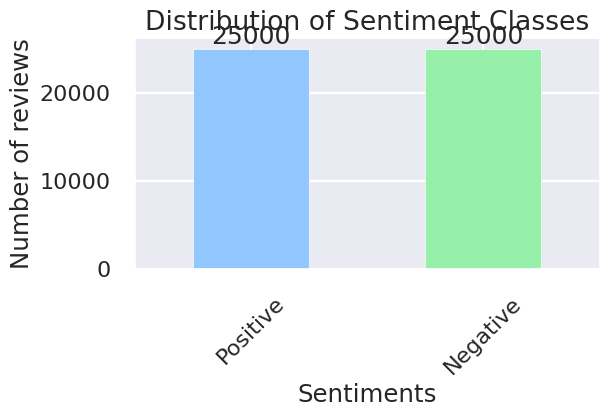

In [ ]:
# Count the number of tweets per sentiment category
sentiment_num = data['sentiment'].value_counts()

# Set the desired colors for the bars
colors = sns.color_palette() #['black'] #, 'yellow', 'green', 'red']

# Define the custom labels and figure size
sentiment_labels = {'positive': 'Positive', 'negative': 'Negative'}
plt.figure(figsize=(6, 3))

# Plot the bar plot
ax = sentiment_num.rename(index=sentiment_labels).plot(kind='bar', color=colors)

# Add precise counts above each bar
for i, count in enumerate(sentiment_num):
    ax.text(i, count, str(count), ha='center', va='bottom')

# Customize xticks and rotation of x-axis labels to improve readability
plt.xticks(range(len(sentiment_labels)), sentiment_labels.values(), rotation=45)

# Add labels and title
plt.xlabel('Sentiments')
plt.ylabel('Number of reviews')
plt.title('Distribution of Sentiment Classes')

# Display the plot
plt.show()


In [ ]:
## Lets take a look at some cells
print(data['review'].iloc[20])
print('-------------------')
print(data['review'].iloc[50])
print('-------------------')
print(data['review'].iloc[70])

After the success of Die Hard and it's sequels it's no surprise really that in the 1990s, a glut of 'Die Hard on a .....' movies cashed in on the wrong guy, wrong place, wrong time concept. That is what they did with Cliffhanger, Die Hard on a mountain just in time to rescue Sly 'Stop or My Mom Will Shoot' Stallone's career.<br /><br />Cliffhanger is one big nit-pickers dream, especially to those who are expert at mountain climbing, base-jumping, aviation, facial expressions, acting skills. All in all it's full of excuses to dismiss the film as one overblown pile of junk. Stallone even managed to get out-acted by a horse! However, if you an forget all the nonsense, it's actually a very lovable and undeniably entertaining romp that delivers as plenty of thrills, and unintentionally, plenty of laughs.<br /><br />You've got to love John Lithgows sneery evilness, his tick every box band of baddies, and best of all, the permanently harassed and hapless 'turncoat' agent, Rex Linn as Travers.

**For better Understanding:** We give context to the review Column by the introduction of 2 Dictionaries to provide more meaning to the review column of the dataset

In [ ]:
contractions = {
    "aren't": "are not",
    "can't": "cannot",
    "couldn't": "could not",
    "didn't": "did not",
    "doesn't": "does not",
    "don't": "do not",
    "hadn't": "had not",
    "hasn't": "has not",
    "haven't": "have not",
    "he'd": "he would",
    "he'll": "he will",
    "he's": "he is",
    "i'd": "I would",
    "i'd": "I had",
    "i'll": "I will",
    "i'm": "I am",
    "isn't": "is not",
    "it's": "it is",
    "it'll": "it will",  # Missing comma here
    "i've": "I have",
    "let's": "let us",
    "mightn't": "might not",
    "mustn't": "must not",
    "shan't": "shall not",
    "she'd": "she would",
    "she'll": "she will",
    "she's": "she is",
    "shouldn't": "should not",
    "that's": "that is",
    "there's": "there is",
    "they'd": "they would",
    "they'll": "they will",
    "they're": "they are",
    "they've": "they have",
    "wasn't": "was not",
    "we'd": "we would",
    "we're": "we are",
    "weren't": "were not",
    "we'll": "we will",
    "we've": "we have",
    "what'll": "what will",
    "what're": "what are",
    "what's": "what is",
    "what've": "what have",
    "where's": "where is",
    "who'd": "who would",
    "who'll": "who will",
    "who's": "who is",
    "who've": "who have",
    "won't": "will not",
    "wouldn't": "would not",
    "you'd": "you would",
    "you'll": "you will",
    "you're": "you are",
    "you've": "you have",
    "'re": " are",
}

contractions = dict((key.lower(), value.lower()) for key,value in contractions.items())

In [ ]:
# Replace shortened words with full words
short = {' BD ': ' Big Deal ',
 ' abt ':' about ',
 ' ab ': ' about ',
 ' fav ': ' favourite ',
 ' fab ': ' fabulous ',
 ' smh ': ' shaking my head ',
 ' u ': ' you ',
 ' c ': ' see ',
 ' anon ': ' anonymous ',
 ' ac ': ' aircon ',
 ' a/c ': ' aircon ',
 ' yo ':' year old ',
 ' n ':' and ',
 ' nd ':' and ',
 ' 2 ': ' to ',
 ' w ': ' with ',
' w/o ': ' without ',
 ' r ': ' are ',
 ' rip ':' rest in peace ',
 ' 4 ' : ' for ',
' BF ': ' Boyfriend ',
' BRB ': ' Be Right Back ',
' BTW ': ' By The Way ',
' GF ': ' Girlfriend ',
' HBD ': ' Happy Birthday ',
' JK ': ' Just Kidding ',
' K ':' Okay ',
' LMK ': ' Let Me Know ',
' LOL ': ' Laugh Out Loud ',
' HA ':' laugh ',
' MYOB ': ' Mind Your Own Business ',
' NBD ': ' No Big Deal ',
' NVM ': ' Nevermind ',
' Obv ':' Obviously ',
' Obvi ':' Obviously ',
' OMG ': ' Oh My God ',
' Pls ': ' Please ',
' Plz ': ' Please ',
' Q ': ' Question ',
' QQ ': ' Quick Question ',
' RLY ': ' Really ',
' SRLSY ': ' Seriously ',
' TMI ': ' Too Much Information ',
' TY ': ' Thank You, ',
' TYVM ': ' Thank You Very Much ',
' YW ': ' You are Welcome ',
' FOMO ': ' Fear Of Missing Out ',
' FTFY ': ' Fixed This For You ',
' FTW ': ' For The Win ',
' FYA ': ' For Your Amusement ',
' FYE ': ' For Your Entertainment ',
' GTI ': ' Going Through It ',
' HTH ': ' Here to Help ',
' IRL ': ' In Real Life ',
' ICYMI ': ' In Case You Missed It ',
' ICYWW ': ' In Case You Were Wondering ',
' NBC ': ' Nobody Cares Though ',
' NTW ': ' Not To Worry ',
' OTD ': ' Of The Day ',
' OOTD ': ' Outfit Of The Day ',
' QOTD ': ' Quote of the Day ',
' FOTD ': ' Find Of the Day ',
' POIDH ': ' Pictures Or It Did ntt Happen ',
' YOLO ': ' You Only Live Once ',
' AFAIK ': ' As Far As I Know ',
' DGYF ': ' Dang Girl You Fine ',
' FWIW ': ' For What It is Worth ',
' IDC ': ' I Do not Care ',
' IDK ': ' I Do not Know ',
' IIRC ': ' If I Remember Correctly ',
' IMHO ': ' In My Honest Opinion ',
' IMO ': ' In My Opinion ',
' Jelly ': ' Jealous ',
' Jellz ': ' Jealous ',
' JSYK ': ' Just So You Know ',
' LMAO ': ' Laughing My Ass Off ',
' LMFAO ': ' Laughing My Fucking Ass Off ',
' NTS ': ' Note to Self ',
' ROFL ': ' Rolling On the Floor Laughing ',
' ROFLMAO ': ' Rolling On the Floor Laughing My Ass Off ',
' SMH ': ' Shaking My Head ',
' TBH ': ' To Be Honest ',
' TL;DR ':  ' Too Long; Did not Read ',
' TLDR ':  ' Too Long; Did not Read ',
' YGTR ': ' You Got That Right ',
' AYKMWTS ': ' Are You Kidding Me With This Shit ',
' BAMF ': ' Bad Ass Mother Fucker ',
' FFS ': ' For Fuck Sake ',
' FML ': ' Fuck My Life ',
' HYFR ': ' Hell Yeah Fucking Right ',
' IDGAF ': ' I Do not Give A Fuck ',
' NFW ': ' No Fucking Way ',
' PITA ': ' Pain In The Ass ',
' POS ': ' Piece of Shit ',
' SOL ': ' Shit Outta Luck ',
' STFU ': ' Shut the Fuck Up ',
' TF ': ' The Fuck ',
' WTF ': ' What The Fuck ',
' BFN ': ' Bye For Now ',
' CU ': ' See You ',
' IC ': ' I see ',
' CYL ': ' See You Later ',
' GTG ': ' Got to Go ',
' OMW ': ' On My Way ',
' RN ': ' Right Now ',
' TTYL ': ' Talk To You Later ',
' TYT ': ' Take Your time ',
' CC ': ' Carbon Copy ',
' CX ': ' Correction ',
' DM ': ' Direct Message ',
' FB ': ' Facebook ',
' FBF ': ' Flash-Back Friday ',
' FF ': ' Follow Friday ',
' HT ': ' Tipping my hat ',
' H/T ': ' Tipping my hat ',
' IG ': ' Instagram ',
' Insta ': ' Instagram ',
' MT ':' Modified Tweet ',
' OH ': ' Overheard ',
' PRT ': ' Partial Retweet ',
' RT ': ' Retweet ',
'rt ' : ' retweet ',
' SO ':' Shout Out ',
' S/O ': ' Shout Out ',
' TBT ': ' Throw-Back Thursday ',
' AWOL ': ' Away While Online ',
' BFF ': ' Best Friend Forever ',
' NSFW ': ' Not Safe For Work ',
' OG ': ' Original Gangster ',
' PSA ': ' Public Service Announcement ',
' PDA ': ' Public Display of Affection '
}

short = dict((key.lower(), value.lower()) for key,value in short.items())

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


caddyshack two good movie compared original cant stack up robe retweet stack horrible replacement ted knight jackie mason funny cant compete rodney dangerfield thank you webb funny character original characters movie lack punch original henry wilcoxon example except hystericly funny lawyer peter blunt played randy quaid every line says reminds originals humor especially scene office i go law suits motions find live come house beat door fing baseball bat make bonfire chippindalemaybe roast golden retriever arff arff arff eat it comin upstairs junior grabbing brooks brothers pjs cramming brand new bmw tight a understanding offsetting small role however dan acroyd obviously replacement bill murray voice beyond irritating everything isnt even funny stupid overall caddyshack ii good movie comparison awesome original cant cut it


In [ ]:
replacement_dict = {**contractions, **short}

def clean_review(text, replacement_dict):

    text = text.lower()  # Convert to lowercase

    # Replace contractions and shortened words with their expanded forms
    for key, value in replacement_dict.items():
        text = text.replace(key, value)

    # Remove stopwords
    stop_words = set(stopwords.words('english'))
    text = ' '.join([word for word in text.split() if word not in stop_words])

    text = text.replace('<br />', '')  # Remove '<br />'
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # Remove URLs
    text = re.sub(r'[^\w\s]', '', text)  # Remove punctuations
    text = re.sub(r'([^\s\w“”]|_)+', '', text)  # Remove non-alphanumeric characters such as repeated punctuation marks
    text = ' '.join(text.split())  # Remove whitespace

    return text.strip()

# Apply the function to create a new column 'review_cleaned'
data['review_cleaned'] = data['review'].apply(lambda x: clean_review(x, replacement_dict))

# View the 70th entry from the 'review_cleaned' column which was viewed before cleaning
print(data['review_cleaned'].iloc[70])

caddyshack two good movie compared original cant stack up robe retweet stack horrible replacement ted knight jackie mason funny cant compete rodney dangerfield thank you webb funny character original characters movie lack punch original henry wilcoxon example except hystericly funny lawyer peter blunt played randy quaid every line says reminds originals humor especially scene office i go law suits motions find live come house beat door fing baseball bat make bonfire chippindalemaybe roast golden retriever arff arff arff eat it comin upstairs junior grabbing brooks brothers pjs cramming brand new bmw tight a understanding offsetting small role however dan acroyd obviously replacement bill murray voice beyond irritating everything isnt even funny stupid overall caddyshack ii good movie comparison awesome original cant cut it


In [ ]:
data.head()

,review,sentiment,review_cleaned
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching 1 oz episode ...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production the filming techni...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...
3,Basically there's a family where a little boy ...,negative,basically family little boy jake thinks zombie...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter matteis love time money visually stunni...


####Simplifying the feature selection process:

1. Wordclouds offer a quick and efficient way to narrow down the vast pool of text data by pinpointing the most representative and frequent words.
2. This focus on prominent terms within each sentiment category will streamline the feature selection process by guiding our attention towards the most relevant and informative data points.
3. By prioritizing these key words, we can build more accurate and insightful models for understanding and classifying sentiment in our data.

In [ ]:
# Word frequencies will lead us to creating word clouds
word_occurence = data['review_cleaned'].str.split(expand=True).stack().value_counts()

In [ ]:
word_occurence[:5]

movie    83510
film     74463
one      50366
like     38826
shout    38621
dtype: int64

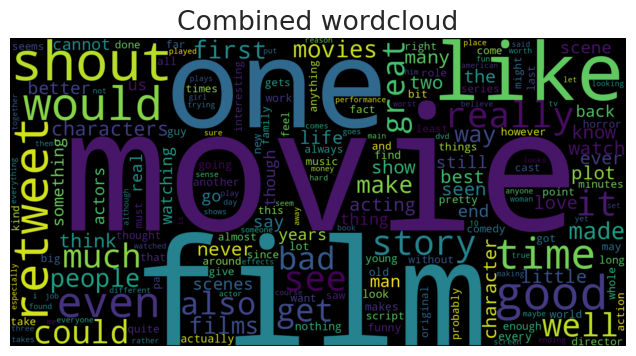

In [ ]:
#we plot a general word cloud
wordcloud = WordCloud(width=1600, height=800).generate_from_frequencies(word_occurence)

# Plot word cloud
plt.figure(figsize=(10, 4))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Combined wordcloud')

# plt.savefig('general_word_cloud.png')
plt.show()

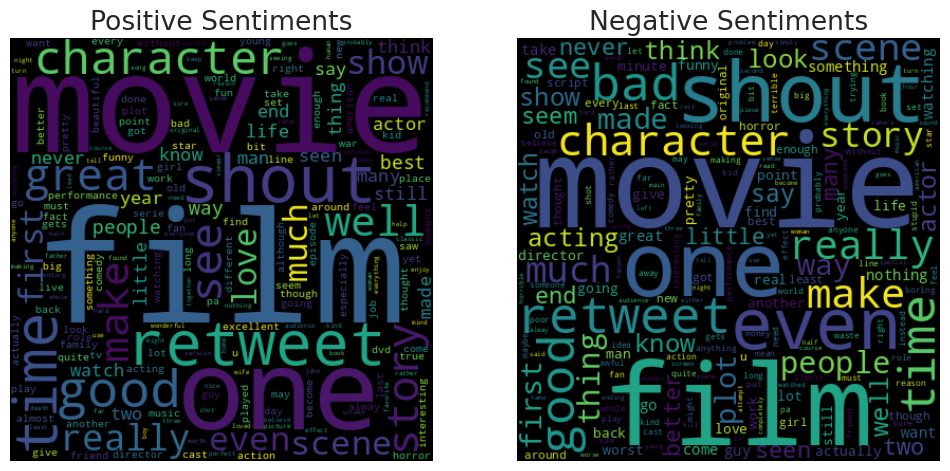

In [ ]:
# Assuming data is your DataFrame with 'sentiment' and 'review_cleaned' columns

# Filter the DataFrame for positive reviews
positive_reviews = data[data['sentiment'] == "positive"]

# Concatenate the text from filtered rows into a single string
text_positive_sentiments = ' '.join(positive_reviews['review_cleaned'])

# Create a word cloud object
wordcloud_positive = WordCloud(max_words=200, width=400, height=400, collocations=False).generate(text_positive_sentiments)

# Filter the DataFrame for negative sentiments
negative_reviews = data[data['sentiment'] == "negative"]

# Concatenate the text from filtered rows into a single string
text_negative_sentiments = ' '.join(negative_reviews['review_cleaned'])

# Create a word cloud object
wordcloud_negative = WordCloud(max_words=200, width=400, height=400, collocations=False).generate(text_negative_sentiments)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Plot the word cloud for positive sentiments
axes[0].imshow(wordcloud_positive, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Positive Sentiments')

# Plot the word cloud for negative sentiments
axes[1].imshow(wordcloud_negative, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Negative Sentiments')

plt.show()


####Lets take a look at the most recurring words

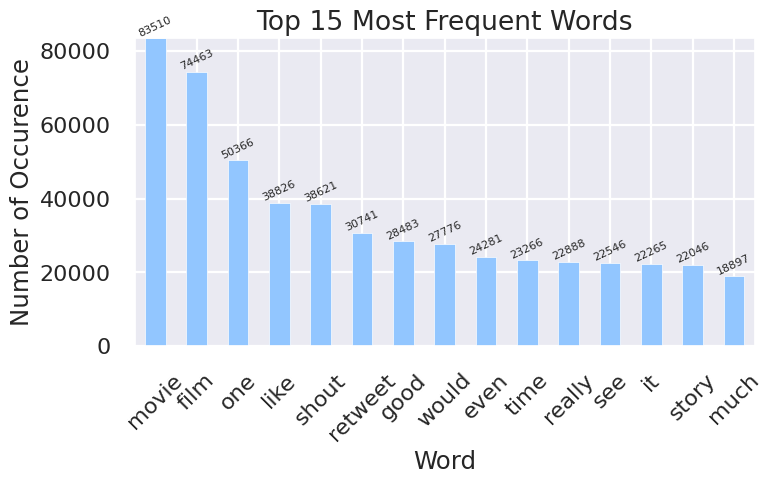

In [ ]:
# Plot top frequent words

# Set the figure size of the plot
plt.figure(figsize=(8, 4))

# Specify the number of top words to display
top_15 = 15

# Select the top 'n' words based on their frequencies and plot a bar chart
word_frequencies_most = word_occurence.head(top_15)
word_frequencies_most.plot(kind='bar')

# Set the x and y-axis labels, plot title and rotation of the x-axis label
plt.xlabel('Word')
plt.ylabel('Number of Occurence')
plt.title(f'Top 15 Most Frequent Words')
plt.xticks(rotation=45)

# Loop through and add precise counts above each bar
for x, y in enumerate(word_frequencies_most):
    plt.text(x, y, str(y), ha='center', va='bottom', fontsize=8, rotation=25)

# Adjust the y-axis limits to provide additional space for the text
plt.ylim(0, max(word_frequencies_most) + 50)

# plt.savefig('top_15_freq_words.jpg')
plt.show()

####Tokenisation and Stemming
1. Tokenisation: To make the text analysis more manageable, we'll first divide the tweets into smaller, more manageable chunks called "tokens." This is like breaking down a long sentence into individual words.
2. Stemming: This helps us capture the core meaning of words, even when they appear in different forms, leading to more accurate analysis.
3. By tokenizing and stemming, we create a more consistent and streamlined representation of the text

In [ ]:
#Tokenizing the clean_review column

tokeniser = TreebankWordTokenizer()
data['tokenised_review'] = data['review_cleaned'].apply(tokeniser.tokenize)

In [ ]:
#Stemming the clean newly created tokens column
stemmer = PorterStemmer()

def df_stemmer(words, stemmer):
    return ' '.join([stemmer.stem(word) for word in words])

#Apply stemming function
data['stemmed_review'] = data['tokenised_review'].apply(df_stemmer, args=(stemmer, ))

In [ ]:
data.head(3)

,review,sentiment,review_cleaned,tokenised_review,stemmed_review
0,One of the other reviewers has mentioned that ...,positive,one reviewers mentioned watching 1 oz episode ...,"[one, reviewers, mentioned, watching, 1, oz, e...",one review mention watch 1 oz episod hook righ...
1,A wonderful little production. <br /><br />The...,positive,wonderful little production the filming techni...,"[wonderful, little, production, the, filming, ...",wonder littl product the film techniqu unassum...
2,I thought this was a wonderful way to spend ti...,positive,thought wonderful way spend time hot summer we...,"[thought, wonderful, way, spend, time, hot, su...",thought wonder way spend time hot summer weeke...


**Preparation of dataset for modelling**
1. Copy as new Dataset
2. Remove unwanted columns
3. Save as new file

In [ ]:
#Copy the dataset
data_m = data.copy()

In [ ]:
#Dropping columns that are not required

data_m = data_m.drop(['review', 'review_cleaned', 'tokenised_review'], axis = 1)

In [ ]:
data_m.head(3)

,sentiment,stemmed_review
0,positive,one review mention watch 1 oz episod hook righ...
1,positive,wonder littl product the film techniqu unassum...
2,positive,thought wonder way spend time hot summer weeke...


In [ ]:
## save processed dataset as a csv file
data_m.to_csv("new_fellowshipAI_dataset.csv", index=False)

#Modelling

In [ ]:
## separate into label and target
X = data['stemmed_review']
y = data['sentiment']

In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

#Transform text data using CountVecorizer
vectorizer = CountVectorizer()
X_vect = vectorizer.fit_transform(X_train)
X_test_vect = vectorizer.transform(X_test)

In [ ]:
## save vectorizer
pickle.dump(vectorizer, open('vectorized.pkl', 'wb'))

**Logistic Regression**


Logistic regression for movie reviews acts like a word-weighing judge, analyzing keywords like "amazing" and "terrible" to predict if a review loved or hated the film. It builds a dividing line based on these word weights, sorting reviews into positive and negative piles for efficient sentiment analysis.

In [ ]:
# Initialize the logistic regression classifier
lr = LogisticRegression(max_iter=1000)

#Train the classifier
lr.fit(X_vect, y_train)

#Make Predictions on the testing data
pred_lr = lr.predict(X_test_vect)

In [ ]:
## save the logistic regression model
pickle.dump(lr, open('logreg_model.pkl', 'wb'))

In [ ]:
# Evaluate model performance
accuracy = accuracy_score(y_test, pred_lr)

print("Linear regression Accuracy:", accuracy)
print ("AUC:", auc)
print('Classification Report')
print(classification_report(y_test, pred_lr, target_names=['negative: Negative', 'positive: Positive']))

Linear regression Accuracy: 0.88384
AUC: <function auc at 0x7dc8d5f8a050>
Classification Report
                    precision    recall  f1-score   support

negative: Negative       0.89      0.88      0.88      6157
positive: Positive       0.88      0.89      0.89      6343

          accuracy                           0.88     12500
         macro avg       0.88      0.88      0.88     12500
      weighted avg       0.88      0.88      0.88     12500



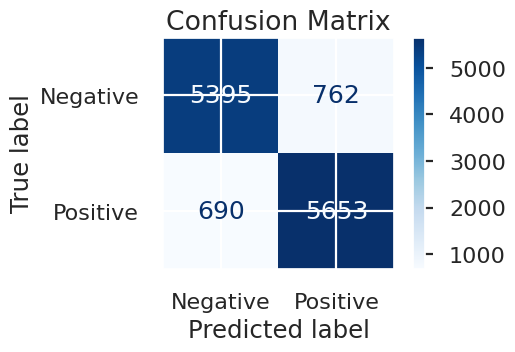

In [ ]:
cm = confusion_matrix(y_test, pred_lr)
fig, ax = plt.subplots(figsize=(5, 3))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix")
plt.show()


**Naive Bayes**


Imagine each movie review as a bag of words, good or bad. Naive Bayes model counts them like a meticulous librarian, comparing positive and negative bags to predict a review's sentiment. It assumes independence between words (no "sad villain = good movie" logic), making it fast and intuitive, but less nuanced than other models.

In [ ]:
#Initialize the model
nb_classifier = MultinomialNB()

# Train the classifier
nb_classifier.fit(X_vect, y_train)

# Make predictions on the testing data
nb_pred = nb_classifier.predict(X_test_vect)

In [ ]:
## save naive bayes model
pickle.dump(nb_classifier, open('nbayes_model.pkl', 'wb'))

In [ ]:
# Evaluate model performance
accuracy = accuracy_score(y_test, nb_pred)

print("NB Accuracy:", accuracy)
print('Classification Report')
print(classification_report(y_test, nb_pred, target_names=['negative: Negative', 'positive: Positive']))

NB Accuracy: 0.8544
Classification Report
                    precision    recall  f1-score   support

negative: Negative       0.84      0.87      0.85      6157
positive: Positive       0.87      0.84      0.85      6343

          accuracy                           0.85     12500
         macro avg       0.85      0.85      0.85     12500
      weighted avg       0.85      0.85      0.85     12500



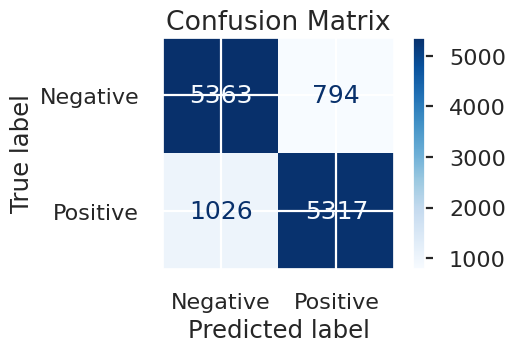

In [ ]:
cm = confusion_matrix(y_test, nb_pred)
fig, ax = plt.subplots(figsize=(5, 3))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix")
plt.show()

**Catboost**


CatBoost, a gradient boosting model, dissects reviews beyond words. Decision trees grow, splitting on keywords, punctuation, and syntax, like a master linguist. It handles categories natively, avoids overfitting, and optimizes for imbalanced data, leaving other models speechless with its nuanced and accurate sentiment predictions.

In [ ]:
import catboost as cb

# Initialize the CatBoost classifier
catboost_model = cb.CatBoostClassifier(
    iterations=1000,  # Number of trees to build
    learning_rate=0.1,  # Step size for gradient descent
    loss_function='Logloss',  # Loss function for binary classification
)

# Train the classifier
catboost_model.fit(X_vect, y_train, verbose=False)  # Set verbose=True for progress updates

# Make predictions on the testing data
catboost_pred = catboost_model.predict(X_test_vect)

# Optional: Get predicted probabilities
catboost_pred_proba = catboost_model.predict_proba(X_test_vect)


In [ ]:
## save naive bayes model
pickle.dump(catboost_model, open('catboost_model.pkl', 'wb'))

In [ ]:
# Evaluate model performance
accuracy = accuracy_score(y_test, catboost_pred)
print("Catboost Accuracy:", accuracy)
print('Classification Report')
print(classification_report(y_test, catboost_pred, target_names=['negative: Negative', 'positive: Positive']))

Catboost Accuracy: 0.85992
Classification Report
                    precision    recall  f1-score   support

negative: Negative       0.88      0.82      0.85      6157
positive: Positive       0.84      0.90      0.87      6343

          accuracy                           0.86     12500
         macro avg       0.86      0.86      0.86     12500
      weighted avg       0.86      0.86      0.86     12500



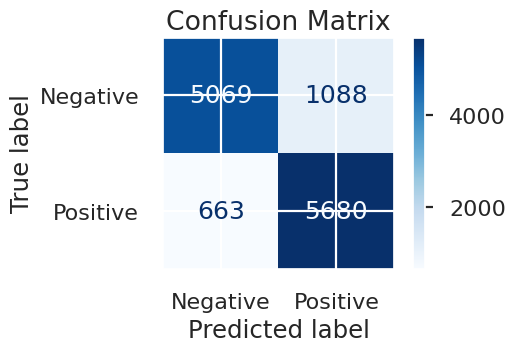

In [ ]:
cm = confusion_matrix(y_test, catboost_pred)
fig, ax = plt.subplots(figsize=(5, 3))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix")
plt.show()

**Random Forest**
Think of a random forest as a crowd of decision trees, each with their own opinion on a review's sentiment. They vote based on word clues like "hilarious" or "clichéd," and the majority wins, giving you the forest's overall verdict: thumbs up or thumbs down. This diversity makes it powerful and flexible, but less transparent than simpler models.

In [ ]:
# Initialize Random Forest classifier
rf_classifier = RandomForestClassifier(n_estimators=100)

# Train the classifier
rf_classifier.fit(X_vect, y_train)

# Make predictions on the testing data
pred_rf = rf_classifier.predict(X_test_vect)

In [ ]:
## save naive bayes model
pickle.dump(rf_classifier, open('rforest_model.pkl', 'wb'))

In [ ]:
# Evaluate model performance
accuracy = accuracy_score(y_test, pred_rf)

print("random forest Accuracy:", accuracy)
print('Classification Report')
print(classification_report(y_test, pred_rf, target_names=['negative: Negative', 'positive: Positive']))

random forest Accuracy: 0.79744
Classification Report
                    precision    recall  f1-score   support

negative: Negative       0.77      0.84      0.80      6157
positive: Positive       0.83      0.76      0.79      6343

          accuracy                           0.80     12500
         macro avg       0.80      0.80      0.80     12500
      weighted avg       0.80      0.80      0.80     12500



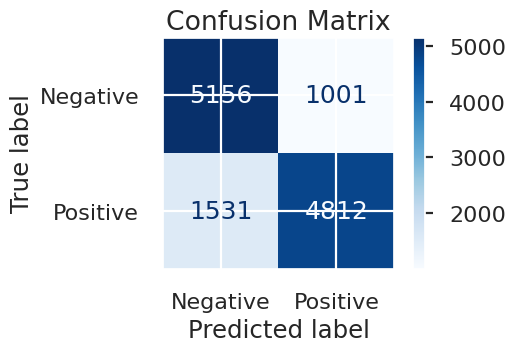

In [ ]:
cm = confusion_matrix(y_test, pred_rf)
fig, ax = plt.subplots(figsize=(5, 3))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title("Confusion Matrix")
plt.show()

#Recommendation

1. The simplicity of the logistic regression model shines through with an outstanding 88.384% accuracy. Its effectiveness in recognizing both positive and negative reviews extends to ease of use, making it a perfect partner for movie producers seeking swift sentiment analysis.
2. A lot more can be done to make this model better and other models can be tried along with hyper parameter tunings.
3. The model can be readily deployed through Streamlit, offering user-friendly access to audience feedback.